# Second-Order Optimizers + SDP on Incremental CIFAR-100
#
**Hypothesis**: SDP + second-order optimizers prevent Loss of Plasticity
on a class-incremental vision benchmark.
#
**Optimizers tested**:
1. **AdaHessian** (Yao et al., 2021) — Hutchinson diagonal Hessian
2. **SophiaH** (Liu et al., 2023) — Hutchinson Hessian + element-wise clipping
3. **Shampoo** (Gupta et al., 2018) — Full-matrix preconditioning
4. **KFAC-NGD** (Martens & Grosse, 2015) — Kronecker-factored natural gradient
5. **SASSHA** (Shin et al., ICML 2025) — SAM + Hutchinson Hessian
#
Each optimizer runs **with and without SDP** for ablation.
#
**Benchmark**: Incremental CIFAR-100 (mlproj_manager / CBP paper setup).
Network: ResNet-18, BatchNorm2d. Classes grow 5 → 100 every 200 epochs.
4000 epochs total, batch size 90 (CBP official).

## 1. Imports & Setup

In [1]:
pip install mlproj-manager==0.0.29

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, copy, time, pickle, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

# ── LoP source path (adjust to your environment) ──
_LOP_ROOT = "/kaggle/input/datasets/mlinh776/lop-src"
if _LOP_ROOT not in sys.path:
    sys.path.insert(0, _LOP_ROOT)

from lop.nets.torchvision_modified_resnet import build_resnet18, kaiming_init_resnet_module
from lop.incremental_cifar.post_run_analysis import compute_dormant_units_proportion

from mlproj_manager.problems import CifarDataSet
from mlproj_manager.util.data_preprocessing_and_transformations import (
    ToTensor, Normalize, RandomCrop, RandomHorizontalFlip, RandomRotator
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## 2. Metrics & SDP

In [3]:
@torch.no_grad()
def compute_avg_weight_magnitude(net):
    n, s = 0, 0.0
    for p in net.parameters():
        n += p.numel()
        s += torch.sum(torch.abs(p)).item()
    return s / n if n > 0 else 0.0

def compute_stable_rank(sv):
    if len(sv) == 0:
        return 0
    sorted_sv = np.flip(np.sort(sv))
    cumsum = np.cumsum(sorted_sv) / np.sum(sv)
    return int(np.sum(cumsum < 0.99) + 1)

def compute_stable_rank_from_activations(act):
    from scipy.linalg import svd
    if act is None:
        return 0
    if isinstance(act, torch.Tensor):
        act = act.detach().cpu().numpy()
    if act.ndim > 2:
        act = act.reshape(act.shape[0], -1)
    if act.shape[0] == 0 or act.shape[1] == 0:
        return 0
    try:
        sv = svd(act, compute_uv=False, lapack_driver="gesvd")
        return compute_stable_rank(sv)
    except Exception:
        return 0

def apply_sdp(net, gamma):
    """Spectral Diversity Preservation (SDP) at task boundary.
    σ'_i = σ̄^γ · σ_i^(1-γ)

    Applies to Conv2d and Linear layers (except the output head).
    Conv2d weights are reshaped to 2D for SVD.
    """
    cond_numbers = []
    modules = [(name, m) for name, m in net.named_modules()
               if isinstance(m, (nn.Linear, nn.Conv2d))]
    with torch.no_grad():
        for i, (name, module) in enumerate(modules):
            is_output_layer = (i == len(modules) - 1)
            if is_output_layer:
                continue  # skip W_out — output head
            W = module.weight.data
            orig_shape = W.shape
            W2d = W.reshape(orig_shape[0], -1)
            try:
                U, S, Vh = torch.linalg.svd(W2d, full_matrices=False)
            except Exception:
                continue
            if S.numel() == 0 or S[0] < 1e-12:
                continue
            cond_numbers.append((S[0] / S[-1].clamp(min=1e-12)).item())
            S_safe = torch.clamp(S, min=1e-4)
            s_mean = S_safe.mean()
            S_new = (s_mean ** gamma) * (S_safe ** (1.0 - gamma))
            W_new = (U @ torch.diag(S_new) @ Vh).reshape(orig_shape)
            module.weight.data.copy_(W_new)
    return cond_numbers

print("✓ Metrics & SDP defined")

✓ Metrics & SDP defined


## 3. Load CIFAR-100

In [4]:
_CIFAR_MEAN = (0.5071, 0.4865, 0.4409)
_CIFAR_STD  = (0.2673, 0.2564, 0.2762)

train_transformations = transforms.Compose([
    ToTensor(swap_color_axis=True),
    Normalize(mean=_CIFAR_MEAN, std=_CIFAR_STD),
    RandomHorizontalFlip(p=0.5),
    RandomCrop(size=32, padding=4, padding_mode="reflect"),
    RandomRotator(degrees=(0, 15)),
])
eval_transformations = transforms.Compose([
    ToTensor(swap_color_axis=True),
    Normalize(mean=_CIFAR_MEAN, std=_CIFAR_STD),
])

data_path = (lambda p: (os.makedirs(p, exist_ok=True), p)[1])("data/cifar100")

train_data_full = CifarDataSet(
    root_dir=data_path, train=True, cifar_type=100,
    device=None, image_normalization="max", label_preprocessing="one-hot", use_torch=True)
test_data = CifarDataSet(
    root_dir=data_path, train=False, cifar_type=100,
    device=None, image_normalization="max", label_preprocessing="one-hot", use_torch=True)


def get_train_val_indices(cifar_data, num_classes=100):
    """Split each class: first 50 → val, remaining 450 → train."""
    val_idx   = torch.zeros(5000,  dtype=torch.int32)
    train_idx = torch.zeros(45000, dtype=torch.int32)
    cv, ct = 0, 0
    for i in range(num_classes):
        ci = torch.argwhere(cifar_data.data["labels"][:, i] == 1).flatten()
        val_idx[cv:cv + 50]      = ci[:50]
        train_idx[ct:ct + 450]   = ci[50:]
        cv += 50; ct += 450
    return train_idx, val_idx


def subsample_cifar(indices, cifar_data):
    idx = indices.numpy() if isinstance(indices, torch.Tensor) else indices
    cifar_data.data["data"]   = cifar_data.data["data"][idx]
    cifar_data.data["labels"] = cifar_data.data["labels"][idx]
    cifar_data.integer_labels = torch.tensor(cifar_data.integer_labels)[idx].tolist()
    cifar_data.current_data   = cifar_data.partition_data()


train_indices, val_indices = get_train_val_indices(train_data_full)
train_data = copy.deepcopy(train_data_full)
val_data   = copy.deepcopy(train_data_full)
subsample_cifar(train_indices, train_data)
subsample_cifar(val_indices,   val_data)
train_data.set_transformation(train_transformations)
val_data.set_transformation(eval_transformations)
test_data.set_transformation(eval_transformations)

print(f"✓ CIFAR-100: Train={len(train_data.data['data'])}, "
      f"Val={len(val_data.data['data'])}, Test={len(test_data.data['data'])}")

100%|██████████| 169M/169M [00:06<00:00, 26.2MB/s]


✓ CIFAR-100: Train=45000, Val=5000, Test=10000


## 4. Optimizer Definitions

### 4a. AdaHessian
Source: https://github.com/davda54/ada-hessian

In [5]:
class Adahessian(Optimizer):
    """AdaHessian — Adaptive second-order optimizer using Hutchinson trace."""
    def __init__(self, params, lr=0.15, betas=(0.9, 0.999), eps=1e-4,
                 weight_decay=0.0, hessian_power=1, lazy_hessian=1,
                 n_samples=1, seed=0):
        if not 0.0 <= lr: raise ValueError(f"Invalid lr: {lr}")
        if not 0.0 <= eps: raise ValueError(f"Invalid eps: {eps}")
        if not 0.0 <= betas[0] < 1.0: raise ValueError(f"Invalid beta0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0: raise ValueError(f"Invalid beta1: {betas[1]}")
        if not 0.0 <= hessian_power <= 1.0: raise ValueError(f"Invalid hessian_power: {hessian_power}")
        self.n_samples = n_samples
        self.lazy_hessian = lazy_hessian
        self.seed = seed
        self.generator = torch.Generator().manual_seed(self.seed)
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
                        hessian_power=hessian_power)
        super().__init__(params, defaults)
        for p in self.get_params():
            p.hess = 0.0
            self.state[p]["hessian step"] = 0

    def get_params(self):
        return (p for group in self.param_groups for p in group['params'] if p.requires_grad)

    def zero_hessian(self):
        for p in self.get_params():
            if not isinstance(p.hess, float) and self.state[p]["hessian step"] % self.lazy_hessian == 0:
                p.hess.zero_()

    @torch.no_grad()
    def set_hessian(self):
        params = []
        for p in filter(lambda p: p.grad is not None, self.get_params()):
            if self.state[p]["hessian step"] % self.lazy_hessian == 0:
                params.append(p)
            self.state[p]["hessian step"] += 1
        if len(params) == 0: return
        if self.generator.device != params[0].device:
            self.generator = torch.Generator(params[0].device).manual_seed(self.seed)
        grads = [p.grad for p in params]
        last_sample = self.n_samples - 1
        for i in range(self.n_samples):
            zs = [torch.randint(0, 2, p.size(), generator=self.generator, device=p.device) * 2.0 - 1.0 for p in params]
            h_zs = torch.autograd.grad(grads, params, grad_outputs=zs, only_inputs=True, retain_graph=i < last_sample)
            for h_z, z, p in zip(h_zs, zs, params):
                p.hess += h_z * z / self.n_samples

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None: loss = closure()
        self.zero_hessian()
        self.set_hessian()
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or p.hess is None: continue
                if p.dim() <= 2:
                    p.hess = p.hess.abs().clone()
                if p.dim() == 4:
                    p.hess = torch.mean(p.hess.abs(), dim=[2, 3], keepdim=True).expand_as(p.hess).clone()
                p.mul_(1 - group['lr'] * group['weight_decay'])
                state = self.state[p]
                if len(state) == 1:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)
                    state['exp_hessian_diag_sq'] = torch.zeros_like(p.data)
                exp_avg, exp_hessian_diag_sq = state['exp_avg'], state['exp_hessian_diag_sq']
                beta1, beta2 = group['betas']
                state['step'] += 1
                exp_avg.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                exp_hessian_diag_sq.mul_(beta2).addcmul_(p.hess, p.hess, value=1 - beta2)
                bias_correction1 = 1 - beta1 ** state['step']
                bias_correction2 = 1 - beta2 ** state['step']
                step_size = group['lr'] / bias_correction1
                k = group['hessian_power']
                denom = (exp_hessian_diag_sq / bias_correction2).pow_(k / 2).add_(group['eps'])
                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

print("✓ AdaHessian defined")

✓ AdaHessian defined


### 4b. SophiaH
Source: https://github.com/Liuhong99/Sophia

In [6]:
class SophiaH(Optimizer):
    """SophiaH — Hutchinson Hessian + element-wise gradient clipping."""
    def __init__(self, params, lr=0.003, betas=(0.965, 0.99), eps=1e-4,
                 weight_decay=0.0, clip_threshold=1.0, lazy_hessian=10,
                 n_samples=1, seed=0):
        if not 0.0 <= lr: raise ValueError(f"Invalid lr: {lr}")
        if not 0.0 <= eps: raise ValueError(f"Invalid eps: {eps}")
        if not 0.0 <= betas[0] < 1.0: raise ValueError(f"Invalid beta0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0: raise ValueError(f"Invalid beta1: {betas[1]}")
        self.n_samples = n_samples
        self.lazy_hessian = lazy_hessian
        self.seed = seed
        self.generator = torch.Generator().manual_seed(self.seed)
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
                        clip_threshold=clip_threshold)
        super().__init__(params, defaults)
        for p in self.get_params():
            p.hess = 0.0
            self.state[p]["hessian step"] = 0

    def get_params(self):
        return (p for group in self.param_groups for p in group['params'] if p.requires_grad)

    def zero_hessian(self):
        for p in self.get_params():
            if not isinstance(p.hess, float) and self.state[p]["hessian step"] % self.lazy_hessian == 0:
                p.hess.zero_()

    @torch.no_grad()
    def set_hessian(self):
        params = []
        for p in filter(lambda p: p.grad is not None, self.get_params()):
            if self.state[p]["hessian step"] % self.lazy_hessian == 0:
                params.append(p)
            self.state[p]["hessian step"] += 1
        if len(params) == 0: return
        if self.generator.device != params[0].device:
            self.generator = torch.Generator(params[0].device).manual_seed(self.seed)
        grads = [p.grad for p in params]
        last_sample = self.n_samples - 1
        for i in range(self.n_samples):
            zs = [torch.randint(0, 2, p.size(), generator=self.generator, device=p.device) * 2.0 - 1.0 for p in params]
            h_zs = torch.autograd.grad(grads, params, grad_outputs=zs, only_inputs=True, retain_graph=i < last_sample)
            for h_z, z, p in zip(h_zs, zs, params):
                p.hess += h_z * z / self.n_samples

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None: loss = closure()
        self.zero_hessian()
        self.set_hessian()
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or p.hess is None: continue
                p.mul_(1 - group['lr'] * group['weight_decay'])
                state = self.state[p]
                if len(state) == 1:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)
                    state['exp_hessian_diag'] = torch.zeros_like(p.data)
                exp_avg, exp_hessian_diag = state['exp_avg'], state['exp_hessian_diag']
                beta1, beta2 = group['betas']
                state['step'] += 1
                exp_avg.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                if (state['hessian step'] - 1) % self.lazy_hessian == 0:
                    exp_hessian_diag.mul_(beta2).add_(p.hess, alpha=1 - beta2)
                step_size = group['lr']
                denom = group['clip_threshold'] * exp_hessian_diag.clamp(0, None) + group['eps']
                ratio = (exp_avg.abs() / denom).clamp(None, 1)
                p.addcmul_(exp_avg.sign(), ratio, value=-step_size)
        return loss

print("✓ SophiaH defined")

✓ SophiaH defined


### 4c. Shampoo
Source: https://github.com/jettify/pytorch-optimizer

In [7]:
MAX_PRECOND_DIM   = 512
MAX_PRECOND_SCALE = 50

def _matrix_power(matrix: torch.Tensor, power: float) -> torch.Tensor:
    device = matrix.device
    dim = matrix.size(0)
    if dim > MAX_PRECOND_DIM:
        diag = matrix.diagonal().clamp(min=1e-4)
        return diag.pow(power).clamp(max=MAX_PRECOND_SCALE).diag().to(device)
    matrix = matrix.cpu().double()
    matrix = 0.5 * (matrix + matrix.t())
    trace_val = matrix.trace().item()
    reg = max(1e-4, 0.01 * abs(trace_val) / dim)
    matrix.diagonal().add_(reg)
    try:
        eigvals, eigvecs = torch.linalg.eigh(matrix)
        eigvals = eigvals.clamp(min=reg)
        return (eigvecs @ eigvals.pow(power).diag() @ eigvecs.t()).float().to(device)
    except torch._C._LinAlgError:
        return torch.eye(dim, device=device)

class Shampoo(Optimizer):
    """Shampoo — Preconditioned Stochastic Tensor Optimization."""
    def __init__(self, params, lr=1e-1, momentum=0.0, weight_decay=0.0,
                 epsilon=1e-4, update_freq=1, precond_decay=0.99):
        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay,
                        epsilon=epsilon, update_freq=update_freq,
                        precond_decay=precond_decay)
        super().__init__(params, defaults)

    def step(self, closure=None):
        loss = None
        if closure is not None: loss = closure()
        for group in self.param_groups:
            decay    = group["precond_decay"]
            momentum = group["momentum"]
            wd       = group["weight_decay"]
            for p in group["params"]:
                if p.grad is None: continue
                grad = p.grad.data.clone()
                order         = grad.ndimension()
                original_size = grad.size()
                state = self.state[p]
                
                if len(state) == 0:
                    state["step"] = 0
                    if momentum > 0:
                        state["momentum_buffer"] = torch.zeros_like(grad)
                    for dim_id, dim in enumerate(grad.size()):
                        state[f"precond_{dim_id}"] = group["epsilon"] * torch.eye(
                            dim, dtype=grad.dtype, device=grad.device)
                        state[f"inv_precond_{dim_id}"] = torch.eye(
                            dim, dtype=grad.dtype, device=grad.device)
                            
                if wd > 0:
                    grad.add_(p.data, alpha=wd)
                if momentum > 0:
                    buf = state["momentum_buffer"]
                    buf.mul_(momentum).add_(grad, alpha=1.0 - momentum)
                    grad = buf.clone()
                
                # 1. Gather condition statistics BEFORE preconditioning
                for dim_id, dim in enumerate(grad.size()):
                    precond     = state[f"precond_{dim_id}"]
                    inv_precond = state[f"inv_precond_{dim_id}"]
                    grad_unfolded = grad.transpose(0, dim_id).contiguous()
                    grad_unfolded = grad_unfolded.view(dim, -1)
                    
                    # Fix: Standard Shampoo (like AdaGrad) uses pure accumulation to naturally decay step size.
                    # EMA bounding keeps preconditioner too small, making Inv_Precond explode gradient norm by 10,000x!
                    precond.add_(grad_unfolded @ grad_unfolded.t())
                    
                    if state["step"] % group["update_freq"] == 0:
                        inv_precond.copy_(_matrix_power(precond, -1.0 / order))
                
                # 2. Correct spatial axes contraction
                update = grad
                for dim_id, dim in enumerate(update.size()):
                    inv_precond = state[f"inv_precond_{dim_id}"]
                    
                    update = update.transpose(0, dim_id).contiguous()
                    transposed_size = update.size()
                    update = update.view(dim, -1)
                    
                    update = inv_precond @ update
                    
                    update = update.view(transposed_size)
                    update = update.transpose(0, dim_id).contiguous()
                    
                state["step"] += 1
                p.data.add_(update, alpha=-group["lr"])
        return loss

print("✓ Shampoo defined")

✓ Shampoo defined


### 4d. K-FAC Natural Gradient Descent
Source: Martens & Grosse, 2015 — "Optimizing Neural Networks with
Kronecker-factored Approximate Curvature"

In [8]:
class KFACOptimizer(Optimizer):
    """
    K-FAC (Kronecker-Factored Approximate Curvature) Natural Gradient Descent.

    Approximates the Fisher Information Matrix for each layer as:
        F ≈ A ⊗ G
    where A = E[x xᵀ] (input covariance), G = E[g gᵀ] (output grad covariance).

    Natural gradient update: ΔW = −η · G⁻¹ ∇W L · A⁻¹

    Supports: nn.Linear, nn.Conv2d. Other layers fall back to SGD.
    """

    def __init__(self, model, lr=0.01, damping=1e-3, weight_decay=0.0,
                 T_inv=100, alpha=0.95, max_grad_norm=1.0):
        """
        Args:
            model: nn.Module to optimize (hooks registered on Conv2d/Linear).
            lr: Learning rate.
            damping: Tikhonov damping λ. sqrt(λ) added to each factor.
            weight_decay: L2 regularization coefficient.
            T_inv: Frequency (in steps) to recompute matrix inverses.
            alpha: EMA coefficient for running A and G stats.
            max_grad_norm: Gradient clipping norm (0 = no clipping).
        """
        self.model = model
        self.damping = damping
        self._init_damp = damping
        self.weight_decay = weight_decay
        self.T_inv = T_inv
        self.alpha = alpha
        self.max_grad_norm = max_grad_norm
        self.steps = 0

        # Storage for Kronecker factors and their inverses
        self._modules_tracked = {}  # name -> module
        self._stats = {}            # name -> {'A': Tensor, 'G': Tensor}
        self._inv = {}              # name -> {'A_inv': ..., 'G_inv': ...}
        self._hooks = []

        defaults = dict(lr=lr)
        super().__init__(model.parameters(), defaults)
        self._register_hooks()
        print(f"  K-FAC tracking {len(self._modules_tracked)} layers")

    def _register_hooks(self):
        """Register forward/backward hooks on Conv2d and Linear layers."""
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Linear, nn.Conv2d)):
                self._modules_tracked[name] = module
                if name not in self._stats:
                    self._stats[name] = {'A': None, 'G': None}
                h1 = module.register_forward_hook(self._forward_hook(name, module))
                h2 = module.register_full_backward_hook(self._backward_hook(name, module))
                self._hooks.append(h1)
                self._hooks.append(h2)

    def _forward_hook(self, name, module):
        """Capture input activations → compute A = E[x xᵀ]."""
        def hook(mod, inp, out):
            if not mod.training:
                return
            with torch.no_grad():
                x = inp[0].detach()
                if isinstance(mod, nn.Conv2d):
                    x = F.unfold(x, mod.kernel_size, dilation=mod.dilation,
                                 padding=mod.padding, stride=mod.stride)
                    x = x.permute(0, 2, 1).reshape(-1, x.size(1))
                elif x.dim() > 2:
                    x = x.reshape(-1, x.size(-1))
                if mod.bias is not None:
                    ones = torch.ones(x.size(0), 1, device=x.device)
                    x = torch.cat([x, ones], dim=1)
                n = x.size(0)
                cov_a = torch.matmul(x.t(), x) / n
                s = self._stats[name]
                if s['A'] is None:
                    s['A'] = cov_a
                else:
                    s['A'].mul_(self.alpha).add_(cov_a, alpha=1 - self.alpha)
        return hook

    def _backward_hook(self, name, module):
        """Capture output gradients → compute G = E[g gᵀ]."""
        def hook(mod, grad_input, grad_output):
            if not mod.training:
                return
            with torch.no_grad():
                g = grad_output[0].detach()
                if isinstance(mod, nn.Conv2d):
                    g = g.permute(0, 2, 3, 1).reshape(-1, g.size(1))
                elif g.dim() > 2:
                    g = g.reshape(-1, g.size(-1))
                n = g.size(0)
                cov_g = torch.matmul(g.t(), g) / n
                s = self._stats[name]
                if s['G'] is None:
                    s['G'] = cov_g
                else:
                    s['G'].mul_(self.alpha).add_(cov_g, alpha=1 - self.alpha)
        return hook

    @torch.no_grad()
    def _invert_factors(self):
        """Invert A and G with damping. Called every T_inv steps."""
        if self.steps < self.T_inv:
            return  # skip warmup — stats too noisy
        sqrt_d = self.damping ** 0.5
        for name in self._stats:
            A = self._stats[name]['A']
            G = self._stats[name]['G']
            if A is None or G is None:
                continue
            try:
                A_d = A + sqrt_d * torch.eye(A.size(0), device=A.device)
                G_d = G + sqrt_d * torch.eye(G.size(0), device=G.device)
                self._inv[name] = {
                    'A_inv': torch.linalg.inv(A_d),
                    'G_inv': torch.linalg.inv(G_d),
                }
            except RuntimeError:
                pass  # keep previous inverse if singular

    def reset_stats(self):
        """Reset running statistics (call at task boundaries)."""
        for name in self._stats:
            self._stats[name] = {'A': None, 'G': None}
        self._inv.clear()
        self.steps = 0
        self.damping = self._init_damp

    def remove_hooks(self):
        """Remove all forward/backward hooks (call before eval)."""
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def reregister_hooks(self):
        """Re-register hooks (call after eval, before next training)."""
        self._register_hooks()

    def state_dict(self):
        """Extended state_dict that includes K-FAC-specific state."""
        sd = super().state_dict()
        # Serialize K-FAC internal state
        sd['kfac_steps'] = self.steps
        sd['kfac_damping'] = self.damping
        sd['kfac_stats'] = {
            name: {
                'A': s['A'].clone() if s['A'] is not None else None,
                'G': s['G'].clone() if s['G'] is not None else None,
            } for name, s in self._stats.items()
        }
        return sd

    def load_state_dict(self, state_dict):
        """Extended load_state_dict that restores K-FAC-specific state."""
        kfac_steps = state_dict.pop('kfac_steps', 0)
        kfac_damping = state_dict.pop('kfac_damping', self._init_damp)
        kfac_stats = state_dict.pop('kfac_stats', None)
        super().load_state_dict(state_dict)
        self.steps = kfac_steps
        self.damping = kfac_damping
        if kfac_stats is not None:
            for name in kfac_stats:
                if name in self._stats:
                    self._stats[name] = kfac_stats[name]
        # Rebuild inverses from restored stats
        self._invert_factors()

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        # Periodically recompute inverses
        if self.steps % self.T_inv == 0:
            self._invert_factors()

        lr = self.param_groups[0]['lr']

        # 1. Compute natural gradients for all tracked layers
        updates = {}
        for name, module in self._modules_tracked.items():
            if module.weight.grad is None:
                continue
            grad_w = module.weight.grad
            has_b = module.bias is not None and module.bias.grad is not None

            if name in self._inv:
                A_inv = self._inv[name]['A_inv']
                G_inv = self._inv[name]['G_inv']

                if isinstance(module, nn.Conv2d):
                    c_out = grad_w.size(0)
                    grad_2d = grad_w.reshape(c_out, -1)
                    if has_b:
                        grad_2d = torch.cat([grad_2d, module.bias.grad.unsqueeze(1)], dim=1)
                    nat_grad = torch.matmul(G_inv, torch.matmul(grad_2d, A_inv))
                    if has_b:
                        nat_grad_w = nat_grad[:, :-1].reshape_as(module.weight)
                        nat_grad_b = nat_grad[:, -1]
                    else:
                        nat_grad_w = nat_grad.reshape_as(module.weight)
                        nat_grad_b = None
                else:  # Linear
                    if has_b:
                        grad_2d = torch.cat([grad_w, module.bias.grad.unsqueeze(1)], dim=1)
                    else:
                        grad_2d = grad_w
                    nat_grad = torch.matmul(G_inv, torch.matmul(grad_2d, A_inv))
                    if has_b:
                        nat_grad_w = nat_grad[:, :-1]
                        nat_grad_b = nat_grad[:, -1]
                    else:
                        nat_grad_w = nat_grad
                        nat_grad_b = None
            else:
                # No inverse available yet → plain SGD fallback
                nat_grad_w = grad_w.clone()
                nat_grad_b = module.bias.grad.clone() if has_b else None

            updates[name] = (nat_grad_w, nat_grad_b)

        # 2. Gradient clipping on natural gradient norm
        clip = 1.0
        if self.max_grad_norm > 0 and len(updates) > 0:
            total_sq = sum(
                ngw.norm().item()**2 + (ngb.norm().item()**2 if ngb is not None else 0.0)
                for ngw, ngb in updates.values()
            )
            if total_sq**0.5 > self.max_grad_norm:
                clip = self.max_grad_norm / (total_sq**0.5 + 1e-6)

        # 3. Apply updates with weight decay
        for name, (nat_grad_w, nat_grad_b) in updates.items():
            module = self._modules_tracked[name]
            if self.weight_decay > 0:
                nat_grad_w = nat_grad_w + self.weight_decay * module.weight
            module.weight.data.add_(nat_grad_w, alpha=-lr * clip)
            if nat_grad_b is not None and module.bias is not None:
                module.bias.data.add_(nat_grad_b, alpha=-lr * clip)

        # 4. SGD for non-tracked parameters (e.g., BatchNorm)
        tracked_params = set()
        for mod in self._modules_tracked.values():
            tracked_params.add(id(mod.weight))
            if mod.bias is not None:
                tracked_params.add(id(mod.bias))

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or id(p) in tracked_params:
                    continue
                if self.weight_decay > 0:
                    p.data.mul_(1.0 - lr * self.weight_decay)
                p.data.add_(p.grad, alpha=-lr)

        self.steps += 1
        return loss

print("✓ KFACOptimizer (K-FAC NGD) defined")

✓ KFACOptimizer (K-FAC NGD) defined


### 4e. SASSHA (reference)
Source: https://github.com/LOG-postech/Sassha (ICML 2025)

In [9]:
class SASSHA(Optimizer):
    """SASSHA — SAM + Hutchinson Hessian trace (ICML 2025)."""
    def __init__(self, params, lr=0.15, betas=(0.9, 0.999), weight_decay=0.0,
                 rho=0.2, lazy_hessian=10, n_samples=1, perturb_eps=1e-12,
                 eps=1e-4, adaptive=False, hessian_power=1.0, seed=0, **kwargs):
        if not 0.0 <= lr: raise ValueError(f"Invalid lr: {lr}")
        if not 0.0 <= eps: raise ValueError(f"Invalid eps: {eps}")
        if not 0.0 <= betas[0] < 1.0: raise ValueError(f"Invalid beta0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0: raise ValueError(f"Invalid beta1: {betas[1]}")
        self.lazy_hessian = lazy_hessian
        self.n_samples = n_samples
        self.adaptive = adaptive
        self.seed = seed
        self.hessian_power_t = hessian_power
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay,
                        rho=rho, perturb_eps=perturb_eps, eps=eps)
        super().__init__(params, defaults)
        for p in self.get_params():
            p.hess = 0.0
            self.state[p]["hessian step"] = 0
        self.generator = torch.Generator().manual_seed(self.seed)

    def get_params(self):
        return (p for group in self.param_groups for p in group['params'] if p.requires_grad)

    def zero_hessian(self):
        for p in self.get_params():
            if not isinstance(p.hess, float) and self.state[p]["hessian step"] % self.lazy_hessian == 0:
                p.hess.zero_()

    @torch.no_grad()
    def set_hessian(self):
        params = []
        for p in filter(lambda p: p.grad is not None, self.get_params()):
            if self.state[p]["hessian step"] % self.lazy_hessian == 0:
                params.append(p)
            self.state[p]["hessian step"] += 1
        if len(params) == 0: return
        if self.generator.device != params[0].device:
            self.generator = torch.Generator(params[0].device).manual_seed(self.seed)
        grads = [p.grad for p in params]
        last_sample = self.n_samples - 1
        for i in range(self.n_samples):
            zs = [torch.randint(0, 2, p.size(), generator=self.generator, device=p.device) * 2.0 - 1.0 for p in params]
            h_zs = torch.autograd.grad(grads, params, grad_outputs=zs, only_inputs=True, retain_graph=i < last_sample)
            for h_z, z, p in zip(h_zs, zs, params):
                p.hess += h_z * z / self.n_samples

    @torch.no_grad()
    def perturb_weights(self, zero_grad=True):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + group["perturb_eps"])
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                if self.adaptive: e_w *= torch.pow(p, 2)
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def unperturb(self):
        for group in self.param_groups:
            for p in group['params']:
                if 'e_w' in self.state[p].keys():
                    p.data.sub_(self.state[p]['e_w'])

    @torch.no_grad()
    def _grad_norm(self, by=None):
        if not by:
            return torch.norm(torch.stack([
                ((torch.abs(p.data) if self.adaptive else 1.0) * p.grad).norm(p=2)
                for group in self.param_groups for p in group["params"] if p.grad is not None
            ]), p=2)
        return torch.norm(torch.stack([
            ((torch.abs(p.data) if self.adaptive else 1.0) * self.state[p][by]).norm(p=2)
            for group in self.param_groups for p in group["params"] if p.grad is not None
        ]), p=2)

    @torch.no_grad()
    def step(self, closure=None, compute_hessian=True):
        loss = None
        if closure is not None: loss = closure()
        if compute_hessian:
            self.zero_hessian()
            self.set_hessian()
        k = self.hessian_power_t
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or p.hess is None: continue
                if isinstance(p.hess, (int, float)):
                    p.hess = torch.zeros_like(p.data)
                else:
                    p.hess = p.hess.abs().clone()
                p.mul_(1 - group['lr'] * group['weight_decay'])
                state = self.state[p]
                if len(state) == 2:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)
                    state['exp_hessian_diag'] = torch.zeros_like(p.data)
                    state['bias_correction2'] = 0
                exp_avg = state['exp_avg']
                exp_hessian_diag = state['exp_hessian_diag']
                beta1, beta2 = group['betas']
                state['step'] += 1
                exp_avg.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                bias_correction1 = 1 - beta1 ** state['step']
                if (state['hessian step'] - 1) % self.lazy_hessian == 0:
                    exp_hessian_diag.mul_(beta2).add_(p.hess, alpha=1 - beta2)
                    bias_correction2 = 1 - beta2 ** state['step']
                    state['bias_correction2'] = bias_correction2 ** k
                step_size = group['lr'] / bias_correction1
                denom = ((exp_hessian_diag ** k) / max(state['bias_correction2'], 1e-12)).add_(group['eps'])
                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

def _disable_running_stats(model):
    """Freeze BatchNorm running stats during SAM perturbation pass."""
    def _disable(module):
        if isinstance(module, nn.BatchNorm2d):
            module.backup_momentum = module.momentum
            module.momentum = 0
    model.apply(_disable)

def _enable_running_stats(model):
    """Restore BatchNorm momentum after SAM perturbation pass."""
    def _enable(module):
        if isinstance(module, nn.BatchNorm2d) and hasattr(module, 'backup_momentum'):
            module.momentum = module.backup_momentum
    model.apply(_enable)

print("✓ SASSHA defined")

✓ SASSHA defined


## 5. EMA Wrapper

In [10]:
class EMAWrapper:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self._shadow = {n: p.data.clone() for n, p in model.named_parameters()}
        self._backup = {}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            self._shadow[n].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    @torch.no_grad()
    def apply(self, model):
        self._backup = {n: p.data.clone() for n, p in model.named_parameters()}
        for n, p in model.named_parameters():
            p.data.copy_(self._shadow[n])

    @torch.no_grad()
    def restore(self, model):
        for n, p in model.named_parameters():
            if n in self._backup:
                p.data.copy_(self._backup[n])
        self._backup.clear()

    @torch.no_grad()
    def reset(self, model):
        self._shadow = {n: p.data.clone() for n, p in model.named_parameters()}

print("✓ EMA wrapper defined")

✓ EMA wrapper defined


## 6. Configs
CBP official: batch=90, lr_milestones=[60,120,160], lr_gamma=0.2, early_stopping=True

In [11]:
NUM_CLASSES = 100
SEED        = 42
CKPT_EVERY  = 200   # save checkpoint to disk every N epochs

# ── Common SDP gamma ──
SDP_GAMMA = 0.3

# ── LR Schedule (CBP-paper style: step-decay within each task, reset at boundary) ──
# All optimizers now use the same schedule from CBP paper (×0.2 at 60/120/160 within each 200-epoch task)
LR_SCHEDULE_PROFILES = {
    'cbp_style':      [(0, 1.0), (60, 0.2), (120, 0.04), (160, 0.008)],
    'none':           [(0, 1.0)],  # fixed LR
}

_SHARED = dict(
    num_epochs=4000,
    batch_size=90,                      # CBP official: 90
    class_increase_frequency=200,       # add 5 new classes every 200 epochs
    use_early_stopping=True,            # load best val model at task boundary
    use_ema=False,
    ema_decay=0.999,
    sdp_freq=50,                        # apply SDP periodically
)

CONFIGS = {
    # ─── 1. AdaHessian + SDP ───
    'adahessian_sdp': dict(
        **_SHARED,
        optimizer='adahessian',
        lr=0.15, betas=(0.9, 0.999), weight_decay=1e-4, eps=1e-4,
        hessian_power=0.5, lazy_hessian=10, n_samples=1,
        sdp_gamma=SDP_GAMMA, lr_schedule='cbp_style',
    ),
    # ─── 2. AdaHessian (no SDP) ───
    'adahessian_nosdp': dict(
        **_SHARED,
        optimizer='adahessian',
        lr=0.01, betas=(0.9, 0.999), weight_decay=5e-4, eps=1e-4,
        hessian_power=1.0, lazy_hessian=10, n_samples=1,
        sdp_gamma=0.0, lr_schedule='cbp_style',
    ),
    # ─── 3. SophiaH + SDP ───
    'sophia_sdp': dict(
        **_SHARED,
        optimizer='sophia',
        lr=0.001, betas=(0.995, 0.99), weight_decay=5e-4, eps=1e-3,
        clip_threshold=0.04, lazy_hessian=1, n_samples=1,
        sdp_gamma=SDP_GAMMA, lr_schedule='none',
    ),
    # ─── 4. SophiaH (no SDP) ───
    'sophia_nosdp': dict(
        **_SHARED,
        optimizer='sophia',
        lr=0.01, betas=(0.965, 0.99), weight_decay=5e-4, eps=1e-3,
        clip_threshold=1.0, lazy_hessian=10, n_samples=1,
        sdp_gamma=0.0, lr_schedule='cbp_style',
    ),
    # ─── 5. Shampoo + SDP ───
    'shampoo_sdp': dict(
        **_SHARED,
        optimizer='shampoo',
        lr=0.01, momentum=0.9, weight_decay=1e-3, epsilon=0.1,
        update_freq=50,
        sdp_gamma=SDP_GAMMA, lr_schedule='cbp_style',
    ),
    # ─── 6. Shampoo (no SDP) ───
    'shampoo_nosdp': dict(
        **_SHARED,
        optimizer='shampoo',
        lr=0.02, momentum=0.9, weight_decay=1e-3, epsilon=0.1,
        update_freq=50,
        sdp_gamma=0.0, lr_schedule='cbp_style',
    ),
    # ─── 7. KFAC-NGD + SDP ───
    'kfac_sdp': dict(
        **_SHARED,
        optimizer='kfac',
        lr=0.003, damping=1e-3, weight_decay=1e-3,
        T_inv=200, alpha=0.9, max_grad_norm=0.0,
        sdp_gamma=SDP_GAMMA, lr_schedule='none',
    ),
    # ─── 8. KFAC-NGD (no SDP) ───
    'kfac_nosdp': dict(
        **_SHARED,
        optimizer='kfac',
        lr=0.15, damping=1e-3, weight_decay=0.0,
        T_inv=50, alpha=0.8, max_grad_norm=0.0,
        sdp_gamma=0.0, lr_schedule='none',
    ),
    # ─── 9. SASSHA + SDP (reference) ───
    'sassha_sdp': dict(
        **_SHARED,
        optimizer='sassha',
        lr=0.15, betas=(0.9, 0.999), weight_decay=1e-3, rho=0.2,
        lazy_hessian=10, n_samples=1, eps=1e-4, hessian_power=0.5,
        sdp_gamma=SDP_GAMMA, lr_schedule='cbp_style',
    ),
    # ─── 10. SASSHA (no SDP) ───
    'sassha_nosdp': dict(
        **_SHARED,
        optimizer='sassha',
        lr=0.05, betas=(0.9, 0.999), weight_decay=1e-3, rho=0.2,
        lazy_hessian=10, n_samples=1, eps=1e-4, hessian_power=1.0,
        sdp_gamma=0.0, lr_schedule='cbp_style',
    ),
}

METHODS_TO_RUN = [
    #'adahessian_sdp', 'adahessian_nosdp',
    #'sophia_sdp',     
    #'sophia_nosdp',
    #'shampoo_sdp',    'shampoo_nosdp',
    'kfac_sdp',       
    #'kfac_nosdp',
    #'sassha_sdp',     
    #'sassha_nosdp',
]

RESULTS_DIR = os.path.join('cifar100_results', 'secondorder_sdp')
CKPT_DIR    = os.path.join(RESULTS_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

import shutil
shutil.copytree(
    "/kaggle/input/datasets/bngtbnh04/checkpoint",
    CKPT_DIR,
    dirs_exist_ok=True
)


print(f"✓ Config: {NUM_CLASSES} classes, 4000 epochs, freq=200, SDP_GAMMA={SDP_GAMMA}")
print(f"  LR schedule profiles: {list(LR_SCHEDULE_PROFILES.keys())}")
print(f"  Methods: {METHODS_TO_RUN}")

✓ Config: 100 classes, 4000 epochs, freq=200, SDP_GAMMA=0.3
  LR schedule profiles: ['cbp_style', 'none']
  Methods: ['kfac_sdp']


## 7. Build Optimizer

In [12]:
def build_optimizer_for_method(config, model):
    """Build the appropriate optimizer from a config dict."""
    opt_type = config['optimizer']

    if opt_type == 'adahessian':
        return Adahessian(
            model.parameters(), lr=config['lr'],
            betas=config.get('betas', (0.9, 0.999)),
            weight_decay=config.get('weight_decay', 0.0),
            eps=config.get('eps', 1e-4),
            hessian_power=config.get('hessian_power', 1.0),
            lazy_hessian=config.get('lazy_hessian', 10),
            n_samples=config.get('n_samples', 1), seed=SEED)

    elif opt_type == 'sophia':
        return SophiaH(
            model.parameters(), lr=config['lr'],
            betas=config.get('betas', (0.965, 0.99)),
            weight_decay=config.get('weight_decay', 0.0),
            eps=config.get('eps', 1e-4),
            clip_threshold=config.get('clip_threshold', 1.0),
            lazy_hessian=config.get('lazy_hessian', 10),
            n_samples=config.get('n_samples', 1), seed=SEED)

    elif opt_type == 'shampoo':
        return Shampoo(
            model.parameters(), lr=config['lr'],
            momentum=config.get('momentum', 0.0),
            weight_decay=config.get('weight_decay', 0.0),
            epsilon=config.get('epsilon', 1e-4),
            update_freq=config.get('update_freq', 50))

    elif opt_type == 'kfac':
        return KFACOptimizer(
            model, lr=config['lr'],
            damping=config.get('damping', 1e-3),
            weight_decay=config.get('weight_decay', 0.0),
            T_inv=config.get('T_inv', 50),
            alpha=config.get('alpha', 0.95),
            max_grad_norm=config.get('max_grad_norm', 1.0))

    elif opt_type == 'sassha':
        return SASSHA(
            model.parameters(), lr=config['lr'],
            betas=config.get('betas', (0.9, 0.999)),
            weight_decay=config.get('weight_decay', 0.0),
            rho=config.get('rho', 0.2),
            lazy_hessian=config.get('lazy_hessian', 10),
            n_samples=config.get('n_samples', 1),
            eps=config.get('eps', 1e-4),
            hessian_power=config.get('hessian_power', 1.0),
            seed=SEED)

    else:
        raise ValueError(f"Unknown optimizer: {opt_type}")

print("✓ build_optimizer_for_method defined")

✓ build_optimizer_for_method defined


## 8. Helper: class schedule

In [13]:
def _num_classes_at_epoch(epoch, freq, initial=5, step=5, max_cls=NUM_CLASSES):
    """Number of active classes at a given epoch (for checkpoint resume).
    Boundaries fire at freq, 2*freq, ... (only when epoch > 0).
    """
    if epoch <= 0:
        return initial
    n_fired = (epoch - 1) // freq
    return min(initial + n_fired * step, max_cls)

def _ckpt_path(method_name: str) -> str:
    return os.path.join(CKPT_DIR, f"ckpt_{method_name}.pt")

def set_lr_for_epoch(optimizer, base_lr, epoch, freq, schedule_name):
    """Step-decay LR schedule within each task, reset at task boundary.
    Mirrors CBP paper: LR resets to base_lr at the start of each task.
    """
    schedule = LR_SCHEDULE_PROFILES.get(schedule_name, [(0, 1.0)])
    epoch_in_task = epoch % freq
    # Find the highest milestone <= epoch_in_task
    multiplier = 1.0
    for milestone, mult in schedule:
        if epoch_in_task >= milestone:
            multiplier = mult
    new_lr = base_lr * multiplier
    for g in optimizer.param_groups:
        g['lr'] = new_lr
    return new_lr

print("✓ Helper functions defined")

✓ Helper functions defined


## 9. Unified Training Loop

In [14]:
def run_method(method_name, config):
    """Unified training loop for all second-order optimizers +/- SDP.

    Incremental CIFAR-100 (CBP-paper setup):
    - ResNet-18 (BatchNorm2d), Kaiming init
    - Start with 5 classes, add 5 every class_increase_frequency epochs
    - Per-task LR schedule with reset at boundary (profile from config)
    - early_stopping: load best val-acc model at task boundary
    - SDP applied at each class boundary when sdp_gamma > 0
    """
    opt_type  = config['optimizer']
    sdp_gamma = config.get('sdp_gamma', 0.0)
    freq      = config['class_increase_frequency']

    print(f"\n{'='*70}")
    print(f"  {method_name} (optimizer={opt_type}) — Incremental CIFAR-100")
    print(f"  lr={config['lr']}  sdp_gamma={sdp_gamma}  ema={config['use_ema']}")
    print(f"  lr_schedule={config.get('lr_schedule', 'none')}  batch={config['batch_size']}")
    print(f"  early_stopping={config.get('use_early_stopping')}")
    print(f"{'='*70}")

    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    np.random.seed(SEED)
    all_classes = np.random.RandomState(SEED).permutation(NUM_CLASSES)

    # ── Build network ──
    net = build_resnet18(num_classes=NUM_CLASSES, norm_layer=nn.BatchNorm2d)
    net.apply(kaiming_init_resnet_module)
    net.to(device)

    optimizer = build_optimizer_for_method(config, net)
    ema = (EMAWrapper(net, config.get('ema_decay', 0.999))
           if config['use_ema'] else None)

    loss_fn = nn.CrossEntropyLoss()
    base_lr = config['lr']
    lr_sched_name = config.get('lr_schedule', 'none')

    metrics = {k: [] for k in [
        'train_loss', 'train_acc', 'val_acc', 'test_acc',
        'dormant_after', 'dormant_before', 'stable_rank',
        'avg_weight_mag', 'overfit_gap', 'epoch_time',
        'sdp_cond_avg', 'lr_history',
    ]}

    # ── Early stopping state ──
    best_val_acc = 0.0
    best_model_state = None

    # ── Resume from checkpoint if available ──
    start_epoch = 0
    ckpt_file = _ckpt_path(method_name)
    if os.path.isfile(ckpt_file):
        ckpt = torch.load(ckpt_file, map_location=device, weights_only=False)
        net.load_state_dict(ckpt['model'])
        try:
            optimizer.load_state_dict(ckpt['optimizer'])
        except Exception as e:
            print(f"  ⚠ Could not restore optimizer state: {e}")
        if ema is not None and 'ema_shadow' in ckpt:
            ema._shadow = ckpt['ema_shadow']
        metrics     = ckpt.get('metrics', metrics)
        # Ensure all expected keys exist (backward compat with older checkpoints)
        for _mk in ['lr_history', 'sdp_cond_avg']:
            if _mk not in metrics:
                metrics[_mk] = []
        start_epoch = ckpt.get('epoch', 0) + 1
        _saved_num_classes = ckpt.get('current_num_classes', None)
        if 'best_val_acc' in ckpt:
            best_val_acc = ckpt['best_val_acc']
        if 'best_model_state' in ckpt:
            best_model_state = ckpt['best_model_state']
        print(f"  ✓ Resumed from epoch {ckpt.get('epoch', 0)}  ({ckpt_file})")
        del ckpt
        torch.cuda.empty_cache()
    else:
        _saved_num_classes = None
        print("  (no checkpoint, training from scratch)")

    current_num_classes = (_saved_num_classes if _saved_num_classes is not None
                           else _num_classes_at_epoch(start_epoch, freq))

    # ── Setup class-incremental data loaders ──
    train_exp = copy.deepcopy(train_data)
    val_exp   = copy.deepcopy(val_data)
    test_exp  = copy.deepcopy(test_data)
    train_exp.select_new_partition(all_classes[:current_num_classes])
    val_exp.select_new_partition(all_classes[:current_num_classes])
    test_exp.select_new_partition(all_classes[:current_num_classes])
    train_loader = DataLoader(train_exp, batch_size=config['batch_size'],
                              shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_exp,   batch_size=50,  shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_exp,  batch_size=100, shuffle=False, num_workers=0)

    # Dormant loaders: measure on next-task and prev-task classes
    dormant_next = copy.deepcopy(train_data_full)
    dormant_prev = copy.deepcopy(train_data_full)
    dormant_next.set_transformation(eval_transformations)
    dormant_prev.set_transformation(eval_transformations)

    def _refresh_dormant_loaders(n_cls):
        ns = n_cls
        ne = min(ns + 5, NUM_CLASSES)
        dorm_next_ldr = None
        dorm_prev_ldr = None
        if ns < NUM_CLASSES:
            dormant_next.select_new_partition(all_classes[ns:ne])
            dorm_next_ldr = DataLoader(dormant_next, batch_size=1000, shuffle=True, num_workers=0)
        if n_cls > 5:
            dormant_prev.select_new_partition(all_classes[:n_cls])
            dorm_prev_ldr = DataLoader(dormant_prev, batch_size=1000, shuffle=True, num_workers=0)
        return dorm_next_ldr, dorm_prev_ldr

    dorm_next_loader, dorm_prev_loader = _refresh_dormant_loaders(current_num_classes)

    # ════════════════════════════════════════════════════════════════
    #  Epoch loop
    # ════════════════════════════════════════════════════════════════
    for epoch in range(start_epoch, config['num_epochs']):
        t0 = time.time()

        sdp_freq = config.get('sdp_freq', 20)
        is_task_boundary = (epoch > 0 and epoch % freq == 0 and current_num_classes < NUM_CLASSES)
        is_sdp_epoch = (epoch > 0 and sdp_gamma > 0 and epoch % sdp_freq == 0)

        # ── Periodic SDP Intervention ──
        if is_sdp_epoch:
            cond_nums = apply_sdp(net, sdp_gamma)
            avg_cond = sum(cond_nums) / max(len(cond_nums), 1)
            metrics['sdp_cond_avg'].append(avg_cond)
            print(f"  SDP applied at epoch {epoch}: avg cond = {avg_cond:.1f}")
            
            # Reset/fade optimizer state to prevent phase mismatch with modified weights
            if opt_type in ('adahessian', 'sophia', 'sassha'):
                for state in optimizer.state.values():
                    if 'exp_avg' in state: state['exp_avg'].mul_(0.5)
                    if 'exp_hessian_diag' in state: state['exp_hessian_diag'].mul_(0.5)
                    if 'exp_hessian_diag_sq' in state: state['exp_hessian_diag_sq'].mul_(0.5)
            elif opt_type == 'kfac':
                # Fade Kronecker factor stats after SDP weight modification
                for name in optimizer._stats:
                    if optimizer._stats[name]['A'] is not None:
                        optimizer._stats[name]['A'].mul_(0.5)
                    if optimizer._stats[name]['G'] is not None:
                        optimizer._stats[name]['G'].mul_(0.5)
                optimizer._inv.clear()  # force re-inversion
            elif opt_type == 'shampoo' and not is_task_boundary:
                # Mild fade for Shampoo mid-task
                for state in optimizer.state.values():
                    dim_id = 0
                    while f"precond_{dim_id}" in state:
                        state[f"precond_{dim_id}"].mul_(0.5)
                        dim_id += 1
        elif is_task_boundary and sdp_gamma <= 0:
            metrics['sdp_cond_avg'].append(float('nan'))

        # ── Task boundary ──
        if is_task_boundary:
            # 0. Early stopping: load best val model before switching task
            if config.get('use_early_stopping', True) and best_model_state is not None:
                net.load_state_dict(best_model_state)
                print(f"  → Early stop: loaded best val (acc={best_val_acc:.4f})")
            best_val_acc = 0.0
            best_model_state = None

            # 2. Reset EMA
            if ema is not None:
                ema.reset(net)

            # 3. Reset Shampoo preconditioners (distribution shift at boundary)
            if opt_type == 'shampoo':
                eps = config.get('epsilon', 0.1)
                for state in optimizer.state.values():
                    state["step"] = 0
                    dim_id = 0
                    while f"precond_{dim_id}" in state:
                        dim = state[f"precond_{dim_id}"].size(0)
                        dev = state[f"precond_{dim_id}"].device
                        dty = state[f"precond_{dim_id}"].dtype
                        state[f"precond_{dim_id}"].copy_(
                            eps * torch.eye(dim, device=dev, dtype=dty))
                        state[f"inv_precond_{dim_id}"].copy_(
                            torch.eye(dim, device=dev, dtype=dty))
                        dim_id += 1

            # 3b. Reset K-FAC stats at task boundary (distribution shift)
            if opt_type == 'kfac':
                optimizer.reset_stats()

            # 4. Expand classes
            current_num_classes = min(current_num_classes + 5, NUM_CLASSES)
            train_exp.select_new_partition(all_classes[:current_num_classes])
            val_exp.select_new_partition(all_classes[:current_num_classes])
            test_exp.select_new_partition(all_classes[:current_num_classes])
            train_loader = DataLoader(train_exp, batch_size=config['batch_size'],
                                      shuffle=True, num_workers=0)
            val_loader   = DataLoader(val_exp,   batch_size=50,  shuffle=False, num_workers=0)
            test_loader  = DataLoader(test_exp,  batch_size=100, shuffle=False, num_workers=0)
            dorm_next_loader, dorm_prev_loader = _refresh_dormant_loaders(current_num_classes)
            print(f"  Task boundary epoch {epoch} → {current_num_classes} classes")

        # ── Set LR for this epoch ──
        current_lr = set_lr_for_epoch(optimizer, base_lr, epoch, freq, lr_sched_name)
        metrics['lr_history'].append(current_lr)

        # ── Train ──
        net.train()
        rl, ra, nb = 0.0, 0.0, 0

        for sample in train_loader:
            img = sample["image"].to(device)
            lbl = sample["label"].to(device)
            tgt = lbl.argmax(1) if lbl.dim() > 1 and lbl.shape[1] > 1 else lbl

            # ── Optimizer-specific training protocol ──
            if opt_type == 'sassha':
                _enable_running_stats(net)
                pred = net(img)[:, all_classes[:current_num_classes]]
                loss = loss_fn(pred, tgt)
                loss.backward()
                optimizer.perturb_weights(zero_grad=True)
                _disable_running_stats(net)
                pred_pert = net(img)[:, all_classes[:current_num_classes]]
                loss_pert = loss_fn(pred_pert, tgt)
                loss_pert.backward(create_graph=True)
                optimizer.unperturb()
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                _enable_running_stats(net)

            elif opt_type == 'kfac':
                # K-FAC NGD: single pass, hooks auto-collect A and G
                optimizer.zero_grad()
                pred = net(img)[:, all_classes[:current_num_classes]]
                loss = loss_fn(pred, tgt)
                loss.backward()
                optimizer.step()

            elif opt_type in ('adahessian', 'sophia'):
                optimizer.zero_grad()
                pred = net(img)[:, all_classes[:current_num_classes]]
                loss = loss_fn(pred, tgt)
                loss.backward(create_graph=True)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            elif opt_type == 'shampoo':
                optimizer.zero_grad()
                pred = net(img)[:, all_classes[:current_num_classes]]
                loss = loss_fn(pred, tgt)
                loss.backward()
                optimizer.step()

            if ema is not None:
                ema.update(net)

            with torch.no_grad():
                pred_eval = net(img)[:, all_classes[:current_num_classes]]
                acc = (pred_eval.argmax(1) == tgt).float().mean().item()
            rl += loss.item(); ra += acc; nb += 1

        avg_loss = rl / nb if nb > 0 else float('nan')
        metrics['train_loss'].append(avg_loss)
        metrics['train_acc'].append(ra / nb if nb > 0 else 0.0)

        # ── Eval (with EMA if available) ──
        if ema is not None:
            ema.apply(net)

        # Remove K-FAC hooks before eval to prevent stats corruption
        if opt_type == 'kfac':
            optimizer.remove_hooks()

        net.eval()
        with torch.no_grad():
            va, vb = 0, 0
            for s in val_loader:
                p = net(s["image"].to(device))[:, all_classes[:current_num_classes]]
                t = s["label"].to(device)
                t = t.argmax(1) if t.dim() > 1 and t.shape[1] > 1 else t
                va += (p.argmax(1) == t).float().mean().item(); vb += 1
            val_acc_e = va / vb if vb else 0.0
            metrics['val_acc'].append(val_acc_e)

            ta, tb = 0, 0
            for s in test_loader:
                p = net(s["image"].to(device))[:, all_classes[:current_num_classes]]
                t = s["label"].to(device)
                t = t.argmax(1) if t.dim() > 1 and t.shape[1] > 1 else t
                ta += (p.argmax(1) == t).float().mean().item(); tb += 1
            test_acc_e = ta / tb if tb else 0.0
            metrics['test_acc'].append(test_acc_e)

        if ema is not None:
            ema.restore(net)

        # ── Track best val accuracy for early stopping ──
        if val_acc_e > best_val_acc:
            best_val_acc = val_acc_e
            best_model_state = copy.deepcopy(net.state_dict())

        # ── Dormant + stable rank (on training model) ──
        bn_bk = {}
        for nm, m in net.named_modules():
            if isinstance(m, nn.BatchNorm2d):
                bn_bk[nm] = {'rm': m.running_mean.clone(),
                             'rv': m.running_var.clone(),
                             'nt': m.num_batches_tracked.clone()}
        net.train()
        with torch.no_grad():
            if dorm_next_loader is not None:
                da, last_act = compute_dormant_units_proportion(net, dorm_next_loader, 0.01)
                sr = compute_stable_rank_from_activations(last_act)
            else:
                da, sr = float('nan'), float('nan')
            for nm, m in net.named_modules():
                if isinstance(m, nn.BatchNorm2d) and nm in bn_bk:
                    m.running_mean.copy_(bn_bk[nm]['rm'])
                    m.running_var.copy_(bn_bk[nm]['rv'])
                    m.num_batches_tracked.copy_(bn_bk[nm]['nt'])
            db = float('nan')
            if dorm_prev_loader is not None:
                db = compute_dormant_units_proportion(net, dorm_prev_loader, 0.01)[0]
            for nm, m in net.named_modules():
                if isinstance(m, nn.BatchNorm2d) and nm in bn_bk:
                    m.running_mean.copy_(bn_bk[nm]['rm'])
                    m.running_var.copy_(bn_bk[nm]['rv'])
                    m.num_batches_tracked.copy_(bn_bk[nm]['nt'])

        # Re-register K-FAC hooks before next training epoch
        if opt_type == 'kfac':
            optimizer.reregister_hooks()

        metrics['dormant_after'].append(da)
        metrics['dormant_before'].append(db)
        metrics['stable_rank'].append(sr)
        wm = compute_avg_weight_magnitude(net)
        metrics['avg_weight_mag'].append(wm)
        metrics['overfit_gap'].append(metrics['train_acc'][-1] - metrics['test_acc'][-1])
        # sdp_cond_avg only has a meaningful value at task boundaries; fill nan otherwise
        if len(metrics['sdp_cond_avg']) < len(metrics['train_loss']):
            metrics['sdp_cond_avg'].append(float('nan'))

        et = time.time() - t0
        metrics['epoch_time'].append(et)

        if epoch % 50 == 0 or epoch == config['num_epochs'] - 1:
            print(f"  [{method_name}] E{epoch} | Loss={avg_loss:.4f} TrainAcc={metrics['train_acc'][-1]:.4f} TestAcc={test_acc_e:.4f} "
                  f"Gap={metrics['overfit_gap'][-1]:.4f} Dorm={db:.4f}/{da:.4f} "
                  f"SRank={sr:.0f} AvgW={wm:.4f} {et:.1f}s")

        # ── Checkpoint ──
        if epoch % CKPT_EVERY == 0 or epoch == config['num_epochs'] - 1:
            ckpt_data = {
                'epoch':               epoch,
                'model':               net.state_dict(),
                'optimizer':           optimizer.state_dict(),
                'metrics':             metrics,
                'current_num_classes': current_num_classes,
                'best_val_acc':        best_val_acc,
                'best_model_state':    best_model_state,
            }
            if ema is not None:
                ckpt_data['ema_shadow'] = ema._shadow
            torch.save(ckpt_data, _ckpt_path(method_name))

    # ── Save final results ──
    result_file = os.path.join(RESULTS_DIR, f'{method_name}_results.pkl')
    with open(result_file, 'wb') as f:
        pickle.dump(metrics, f)
    print(f"  ✓ Results saved to {result_file}")
    return metrics

print("✓ Unified training loop defined")

✓ Unified training loop defined


## 10. Run All Experiments

In [15]:
all_results = {}
for method in METHODS_TO_RUN:
    all_results[method] = run_method(method, CONFIGS[method])

with open(os.path.join(RESULTS_DIR, 'all_results.pkl'), 'wb') as f:
    pickle.dump(all_results, f)
print(f"\n✓ All results saved to {RESULTS_DIR}/all_results.pkl")


  kfac_sdp (optimizer=kfac) — Incremental CIFAR-100
  lr=0.003  sdp_gamma=0.3  ema=False
  lr_schedule=none  batch=90
  early_stopping=True
  K-FAC tracking 21 layers
  ✓ Resumed from epoch 3200  (cifar100_results/secondorder_sdp/checkpoints/ckpt_kfac_sdp.pt)


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


  SDP applied at epoch 3250: avg cond = 2.8
  [kfac_sdp] E3250 | Loss=0.0056 TrainAcc=0.9998 TestAcc=0.6788 Gap=0.3210 Dorm=0.0000/0.0000 SRank=483 AvgW=0.0500 46.4s
  SDP applied at epoch 3300: avg cond = 2.2
  [kfac_sdp] E3300 | Loss=0.0030 TrainAcc=1.0000 TestAcc=0.6886 Gap=0.3114 Dorm=0.0000/0.0000 SRank=484 AvgW=0.0469 46.6s
  SDP applied at epoch 3350: avg cond = 2.7
  [kfac_sdp] E3350 | Loss=0.0069 TrainAcc=1.0000 TestAcc=0.6846 Gap=0.3154 Dorm=0.0000/0.0000 SRank=483 AvgW=0.0517 46.9s
  SDP applied at epoch 3400: avg cond = 2.2
  → Early stop: loaded best val (acc=0.6962)
  Task boundary epoch 3400 → 90 classes
  [kfac_sdp] E3400 | Loss=0.3804 TrainAcc=0.9576 TestAcc=0.6280 Gap=0.3296 Dorm=0.0000/0.0000 SRank=482 AvgW=0.0491 49.4s
  SDP applied at epoch 3450: avg cond = 3.0
  [kfac_sdp] E3450 | Loss=0.0064 TrainAcc=0.9998 TestAcc=0.6774 Gap=0.3223 Dorm=0.0000/0.0000 SRank=483 AvgW=0.0528 49.3s
  SDP applied at epoch 3500: avg cond = 2.8
  [kfac_sdp] E3500 | Loss=0.1687 TrainAcc

## 11. Results Plots

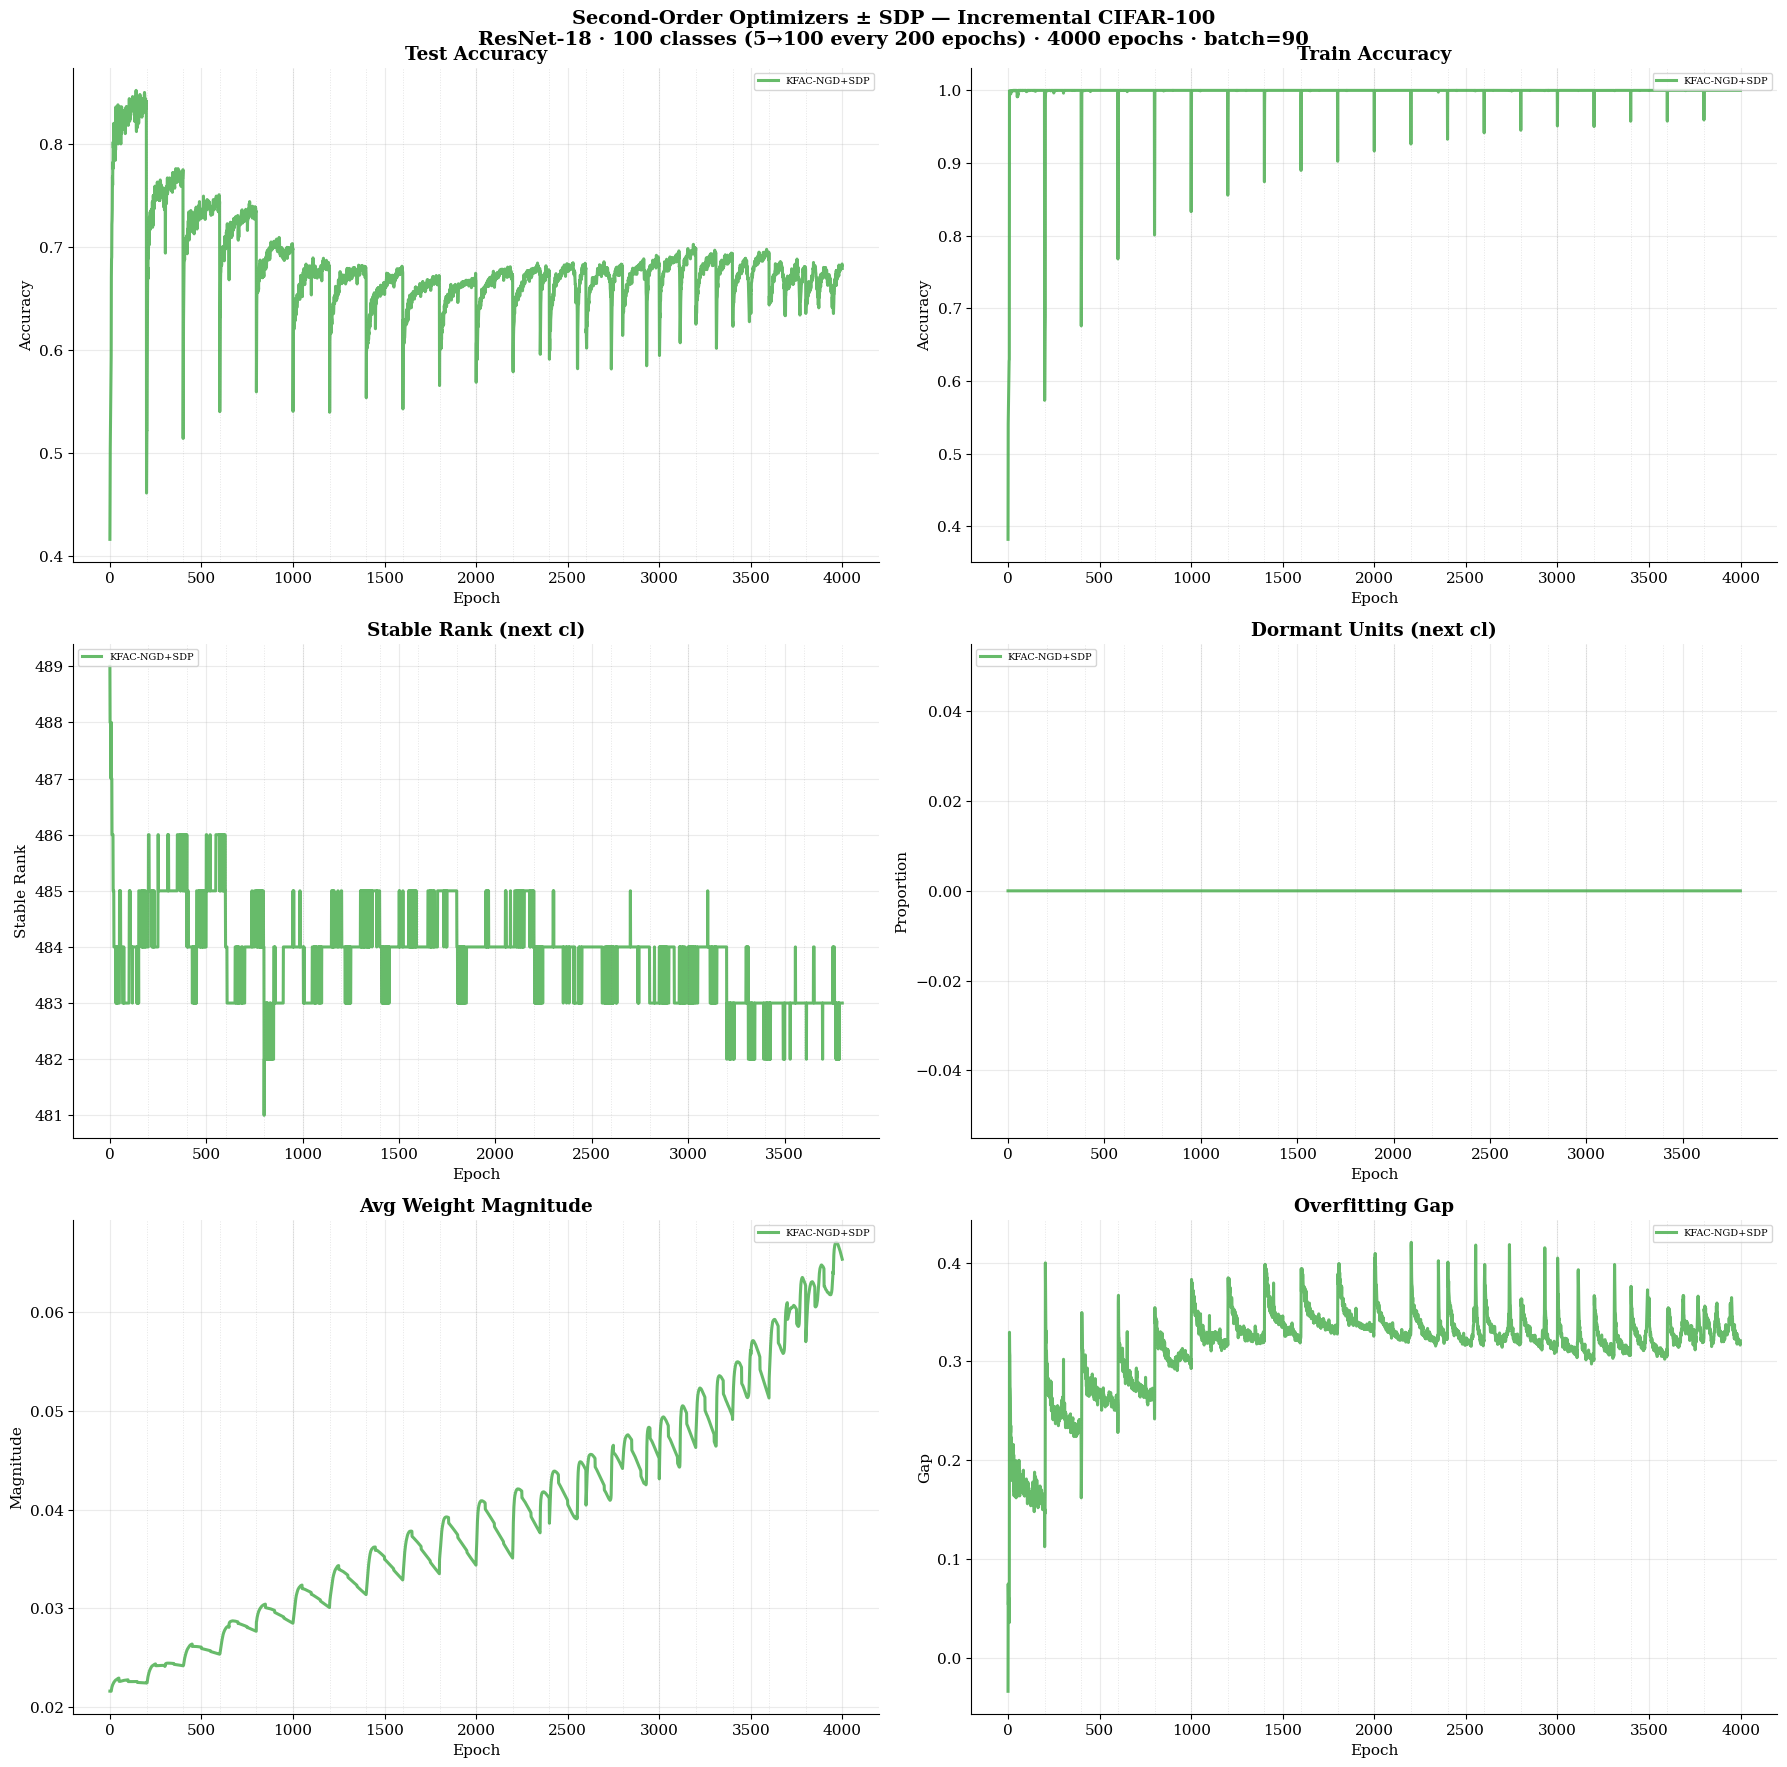

✓ Main comparison plot saved to cifar100_results/secondorder_sdp/secondorder_sdp_comparison.png


In [16]:
# Color palette: SDP variants = solid, no-SDP = dashed
METHOD_STYLES = {
    'adahessian_sdp':   {'color': '#E91E63', 'ls': '-',  'lw': 2.2, 'label': 'AdaHessian+SDP'},
    'adahessian_nosdp': {'color': '#E91E63', 'ls': '--', 'lw': 1.6, 'label': 'AdaHessian'},
    'sophia_sdp':       {'color': '#9C27B0', 'ls': '-',  'lw': 2.2, 'label': 'SophiaH+SDP'},
    'sophia_nosdp':     {'color': '#9C27B0', 'ls': '--', 'lw': 1.6, 'label': 'SophiaH'},
    'shampoo_sdp':      {'color': '#FF9800', 'ls': '-',  'lw': 2.2, 'label': 'Shampoo+SDP'},
    'shampoo_nosdp':    {'color': '#FF9800', 'ls': '--', 'lw': 1.6, 'label': 'Shampoo'},
    'kfac_sdp':         {'color': '#4CAF50', 'ls': '-',  'lw': 2.2, 'label': 'KFAC-NGD+SDP'},
    'kfac_nosdp':       {'color': '#4CAF50', 'ls': '--', 'lw': 1.6, 'label': 'KFAC-NGD'},
    'sassha_sdp':       {'color': '#2196F3', 'ls': '-',  'lw': 2.5, 'label': 'SASSHA+SDP'},
    'sassha_nosdp':     {'color': '#2196F3', 'ls': '--', 'lw': 1.6, 'label': 'SASSHA'},
}

def _style(method):
    return METHOD_STYLES.get(method, {'color': 'gray', 'ls': '-', 'lw': 1.5, 'label': method})

def _clean(ax, freq=200, n_epochs=4000):
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for tb in range(freq, n_epochs, freq):
        ax.axvline(x=tb, color='gray', ls=':', alpha=0.2, lw=0.7)

# ── Main comparison: 3×2 grid ──
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Second-Order Optimizers ± SDP — Incremental CIFAR-100\n'
             f'ResNet-18 · {NUM_CLASSES} classes (5→100 every 200 epochs) · 4000 epochs · batch=90',
             fontsize=14, fontweight='bold')

_FREQ = CONFIGS['sassha_sdp']['class_increase_frequency']

plot_info_main = [
    (axes[0, 0], 'test_acc',       'Test Accuracy',         'Accuracy',       False),
    (axes[0, 1], 'train_acc',      'Train Accuracy',        'Accuracy',       False),
    (axes[1, 0], 'stable_rank',    'Stable Rank (next cl)', 'Stable Rank',    False),
    (axes[1, 1], 'dormant_after',  'Dormant Units (next cl)','Proportion',    False),
    (axes[2, 0], 'avg_weight_mag', 'Avg Weight Magnitude',  'Magnitude',      False),
    (axes[2, 1], 'overfit_gap',    'Overfitting Gap',       'Gap',            False),
]

for ax, key, title, ylabel, use_log in plot_info_main:
    for m, d in all_results.items():
        if key not in d or not d[key]:
            continue
        s = _style(m)
        y = np.array(d[key], dtype=float)
        ax.plot(np.arange(len(y)), y, color=s['color'], ls=s['ls'], lw=s['lw'],
                label=s['label'], alpha=0.85)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, ncol=2)
    if use_log:
        ax.set_yscale('log')
    _clean(ax, _FREQ)

plt.tight_layout()
plot_file = os.path.join(RESULTS_DIR, 'secondorder_sdp_comparison.png')
plt.savefig(plot_file, dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Main comparison plot saved to {plot_file}")

## 12. SDP Ablation: Δ(metric) = SDP − noSDP

/tmp/ipykernel_44/1074945600.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes_ab[i].legend(fontsize=9)


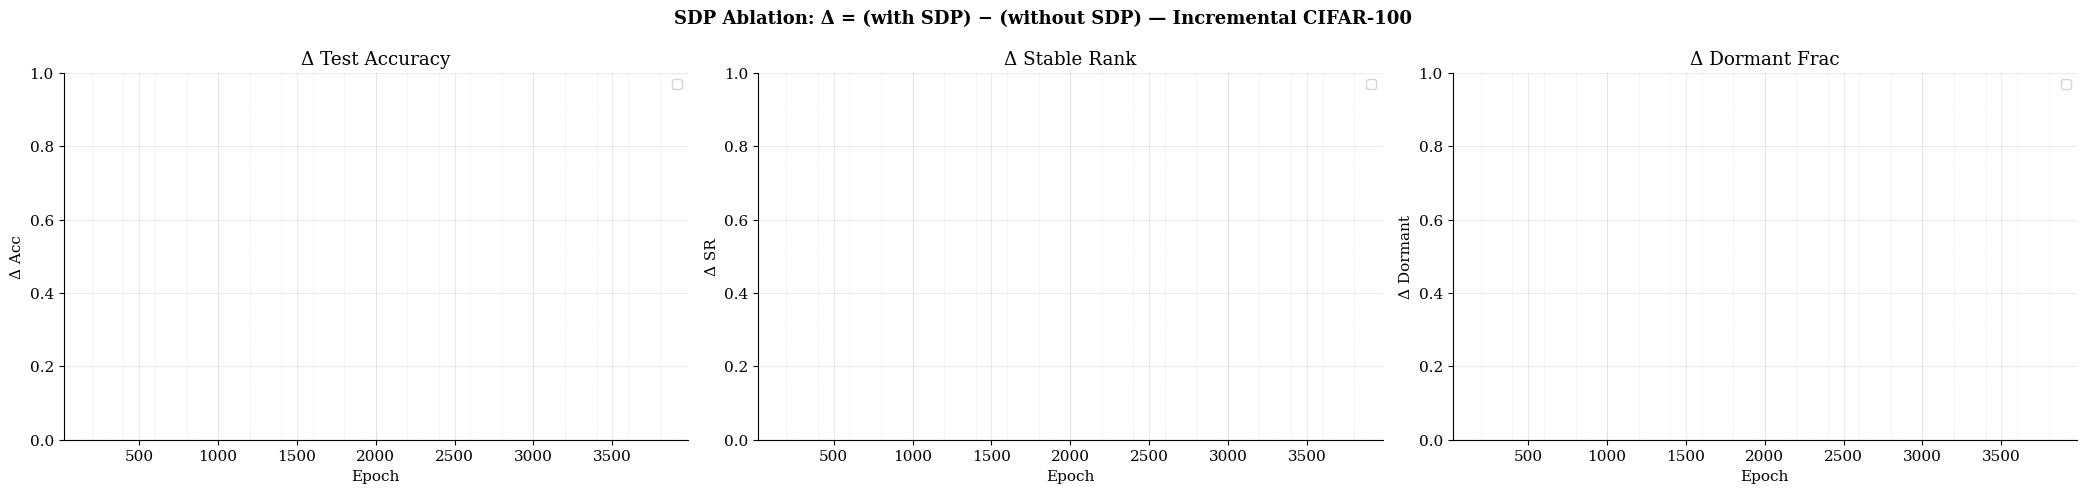

✓ SDP ablation plot saved to cifar100_results/secondorder_sdp/sdp_ablation.png


In [17]:
OPT_PAIRS = [
    ('adahessian_sdp', 'adahessian_nosdp', 'AdaHessian', '#E91E63'),
    ('sophia_sdp',     'sophia_nosdp',     'SophiaH',    '#9C27B0'),
    ('shampoo_sdp',    'shampoo_nosdp',    'Shampoo',    '#FF9800'),
    ('kfac_sdp',       'kfac_nosdp',       'KFAC-NGD',   '#4CAF50'),
    ('sassha_sdp',     'sassha_nosdp',     'SASSHA',     '#2196F3'),
]

fig_ab, axes_ab = plt.subplots(1, 3, figsize=(21, 5))
fig_ab.suptitle('SDP Ablation: Δ = (with SDP) − (without SDP) — Incremental CIFAR-100',
                fontsize=13, fontweight='bold')

for sdp_key, nosdp_key, label, color in OPT_PAIRS:
    if sdp_key not in all_results or nosdp_key not in all_results:
        continue
    d_sdp = all_results[sdp_key]
    d_no  = all_results[nosdp_key]

    na = min(len(d_sdp['test_acc']), len(d_no['test_acc']))
    nb = min(len(d_sdp['stable_rank']), len(d_no['stable_rank']))
    nc = min(len(d_sdp['dormant_after']), len(d_no['dormant_after']))

    # Δ Test Accuracy
    delta_test = np.array(d_sdp['test_acc'][:na]) - np.array(d_no['test_acc'][:na])
    axes_ab[0].plot(np.arange(na), delta_test, color=color, lw=2.0, label=label)

    # Δ Stable Rank
    delta_sr = np.array(d_sdp['stable_rank'][:nb], dtype=float) - np.array(d_no['stable_rank'][:nb], dtype=float)
    axes_ab[1].plot(np.arange(nb), delta_sr, color=color, lw=2.0, label=label)

    # Δ Dormant Fraction
    delta_dorm = np.array(d_sdp['dormant_after'][:nc], dtype=float) - np.array(d_no['dormant_after'][:nc], dtype=float)
    axes_ab[2].plot(np.arange(nc), delta_dorm, color=color, lw=2.0, label=label)

for i, (title, ylabel) in enumerate([
    ('Δ Test Accuracy', 'Δ Acc'),
    ('Δ Stable Rank',   'Δ SR'),
    ('Δ Dormant Frac',  'Δ Dormant'),
]):
    axes_ab[i].set_title(title); axes_ab[i].set_xlabel('Epoch')
    axes_ab[i].set_ylabel(ylabel)
    axes_ab[i].axhline(0, color='black', ls=':', lw=0.8, alpha=0.5)
    axes_ab[i].legend(fontsize=9)
    _clean(axes_ab[i], _FREQ)

plt.tight_layout()
plot_abl = os.path.join(RESULTS_DIR, 'sdp_ablation.png')
plt.savefig(plot_abl, dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ SDP ablation plot saved to {plot_abl}")

## 13. Summary Table

In [18]:
n_final = 200  # last 200 epochs

print(f"\n{'='*110}")
print(f"  Second-Order Optimizers ± SDP — Final {n_final}-epoch average — Incremental CIFAR-100")
print(f"{'='*110}")
header = (f"{'Method':<24} {'TestAcc%':>9} {'TrainAcc%':>10} {'Gap%':>7} "
          f"{'Dormant':>8} {'StbRank':>8} {'AvgW':>8} {'Time/ep':>9}")
print(header)
print(f"{'─'*110}")

for method in METHODS_TO_RUN:
    if method not in all_results: continue
    d  = all_results[method]
    s  = _style(method)
    ta = np.nanmean(d['test_acc'][-n_final:])   * 100
    tr = np.nanmean(d['train_acc'][-n_final:])  * 100
    gp = np.nanmean(d['overfit_gap'][-n_final:]) * 100
    do = np.nanmean(d['dormant_after'][-n_final:])
    sr = np.nanmean(d['stable_rank'][-n_final:])
    wm = np.nanmean(d['avg_weight_mag'][-n_final:])
    et = np.nanmean(d['epoch_time'])
    print(f"  {s['label']:<22} {ta:>9.2f} {tr:>10.2f} {gp:>7.2f} "
          f"{do:>8.4f} {sr:>8.1f} {wm:>8.4f} {et:>8.1f}s")

print(f"{'='*110}")


  Second-Order Optimizers ± SDP — Final 200-epoch average — Incremental CIFAR-100
Method                    TestAcc%  TrainAcc%    Gap%  Dormant  StbRank     AvgW   Time/ep
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  KFAC-NGD+SDP               66.66      99.98   33.32      nan      nan   0.0633     29.0s


/tmp/ipykernel_44/1098140166.py:18: RuntimeWarning: Mean of empty slice
  do = np.nanmean(d['dormant_after'][-n_final:])
/tmp/ipykernel_44/1098140166.py:19: RuntimeWarning: Mean of empty slice
  sr = np.nanmean(d['stable_rank'][-n_final:])
